libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
/tmp/ipykernel_32318/4191184348.py:138: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  pickle.dump(fig, f)


Plot saved as logs/error_analysis_plt_Aug15_12_46.fig.pickle
Data saved as logs/error_analysis_results_Aug15_12_46.csv


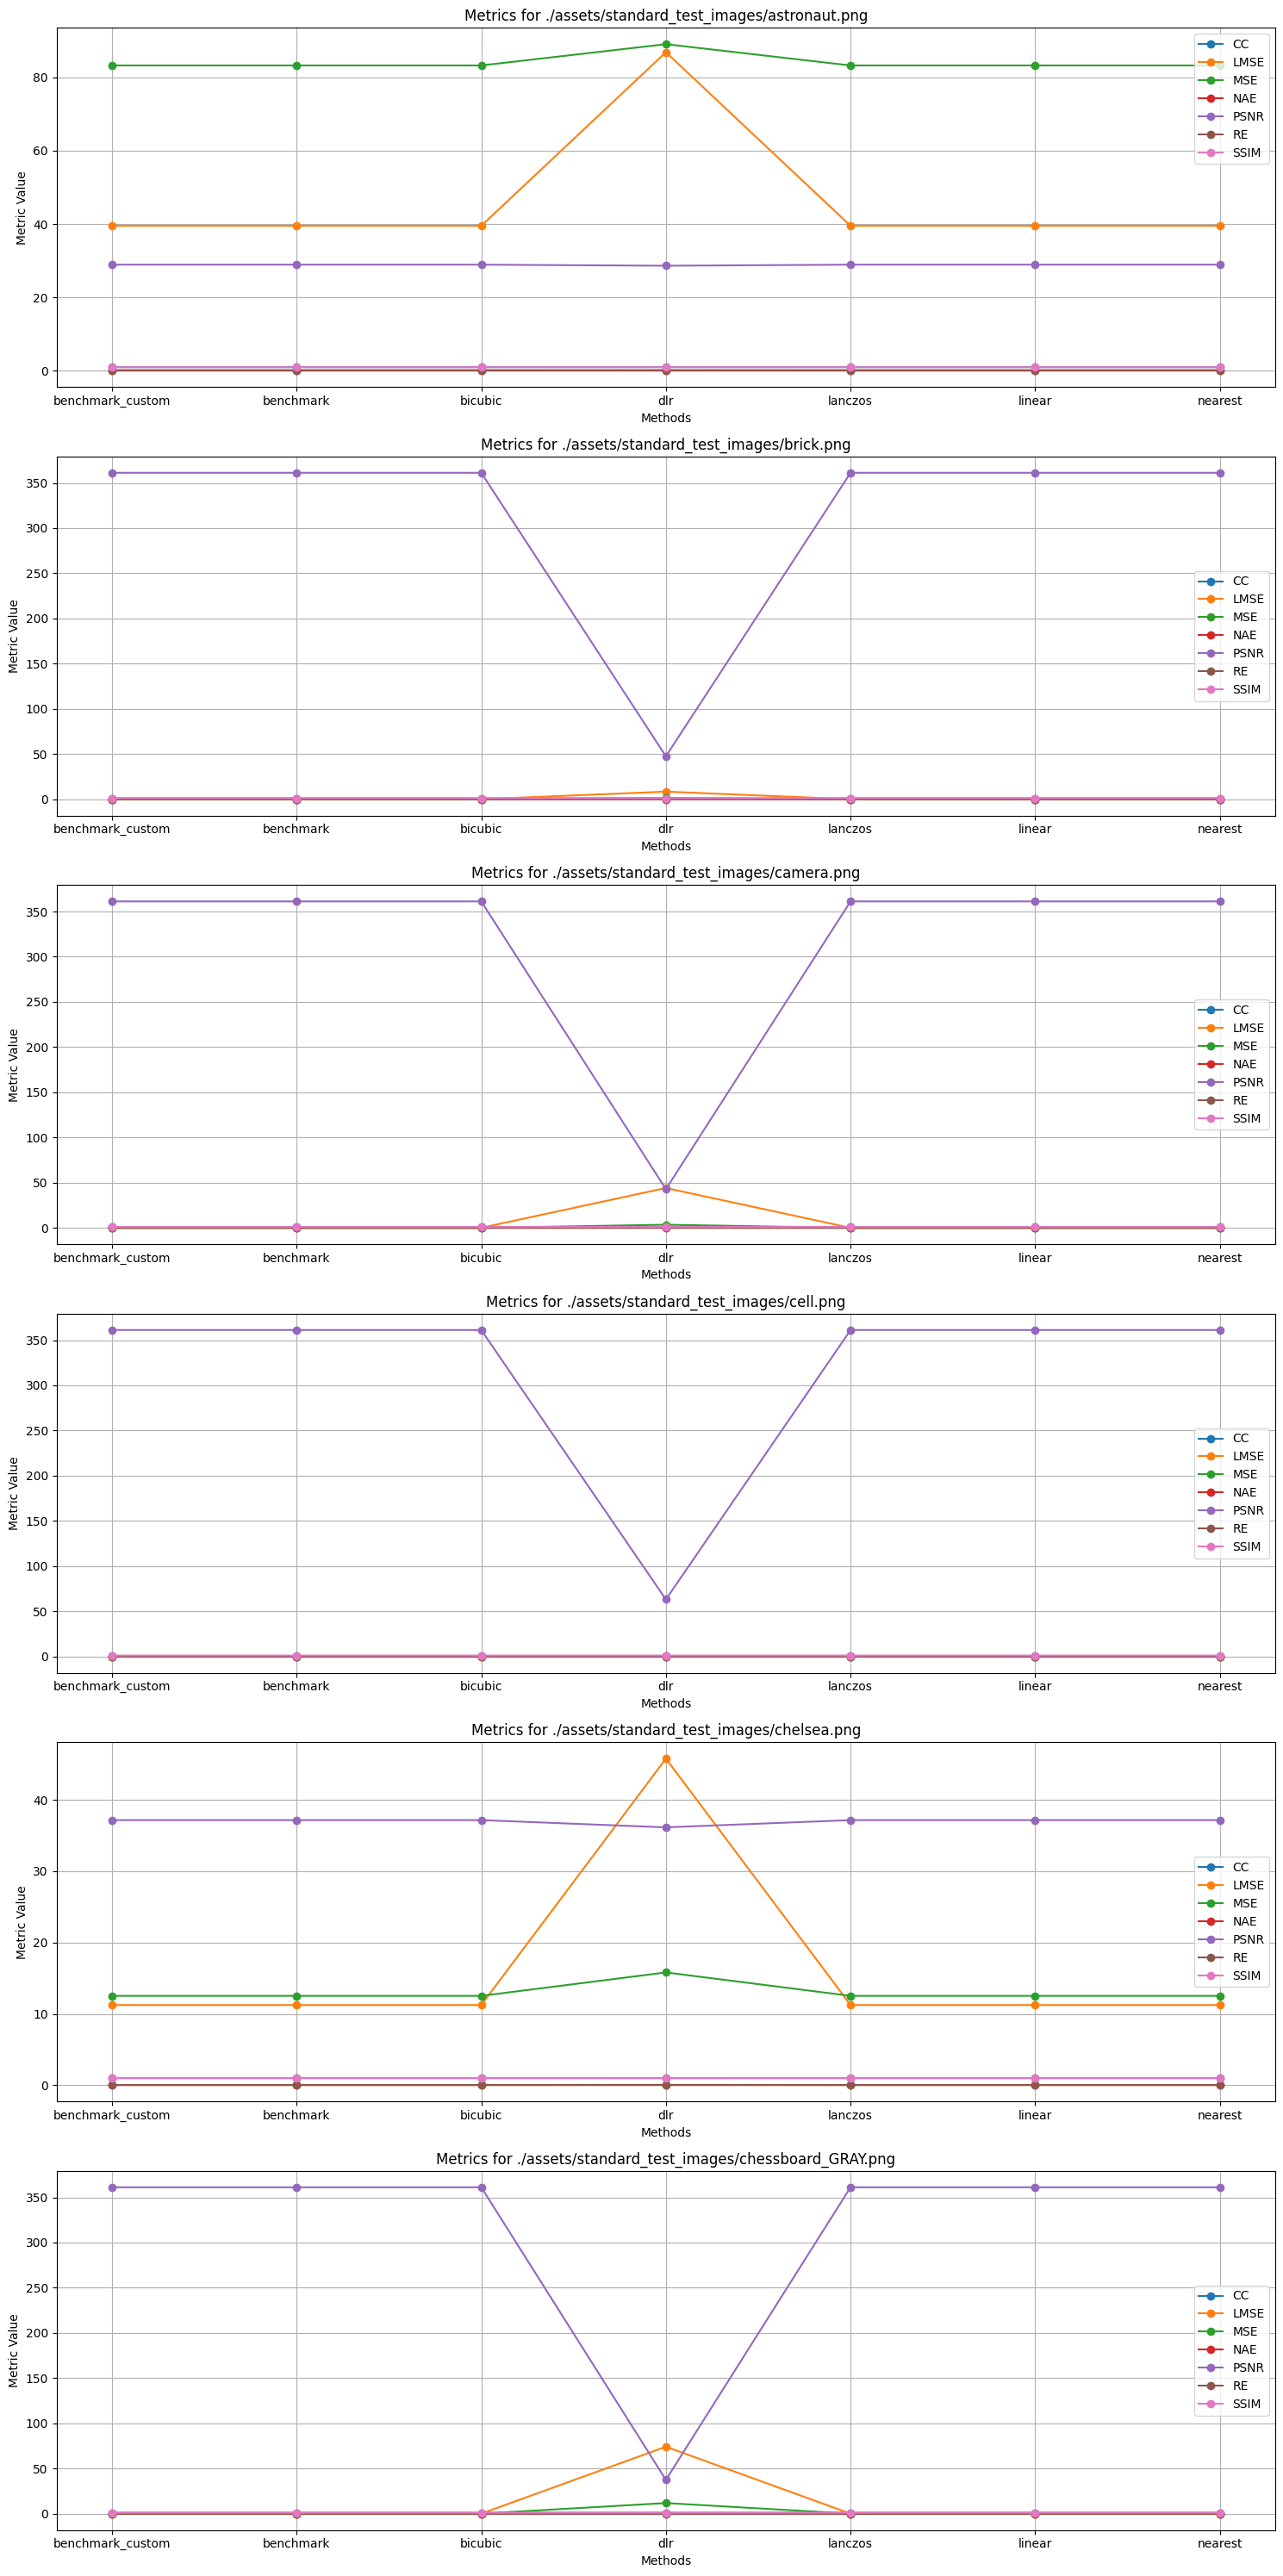

In [6]:
import json
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import csv
from datetime import datetime
import pickle


def psnr(original, processed):
    # mse = np.mean((original - processed) ** 2)
    # if mse == 0:
    #     return float('inf')
    # max_pixel_value = 255.0
    # psnr = 20 * np.log10(max_pixel_value / np.sqrt(mse))
    # return psnr
    return cv2.PSNR(original, processed)


def nae(original, processed):
    # Ensure the images are in floating point format to avoid integer overflow
    original = original.astype(np.float64)
    processed = processed.astype(np.float64)

    # Compute the NAE
    numerator = np.sum(np.abs(original - processed))
    denominator = np.sum(np.abs(original))

    return numerator / denominator


def cc(original, processed):
    original = original.flatten()
    processed = processed.flatten()
    cc = np.corrcoef(original, processed)[0, 1]
    return cc


# def cc(original, processed):
#     return np.sum(original * processed) / np.sum(original * original)


def lmse(original, processed):
    laplacian_original = cv2.Laplacian(original, cv2.CV_64F)
    laplacian_processed = cv2.Laplacian(processed, cv2.CV_64F)
    mse = np.mean((laplacian_original - laplacian_processed) ** 2)
    return mse


def mse(original, processed):
    # the 'Mean Squared Error' between the two images is the
    # sum of the squared difference between the two images;
    # NOTE: the two images must have the same dimension
    err = np.sum((original.astype("float") - processed.astype("float")) ** 2)
    err /= float(original.shape[0] * original.shape[1])

    # return the MSE, the lower the error, the more "similar"
    # the two images are
    return err


def re(original, processed):
    re = np.sum(np.abs(original - processed)) / np.sum(np.abs(original))
    return re


with open("logs/stuff_tested.json", mode="r", encoding="utf-8") as f:
    data = json.load(f)

results = {
    img: {
        "methods": [_.split("/")[-1][:-3] for _ in data["binaries"]],
        "PSNR": [],
        "NAE": [],
        "CC": [],
        "LMSE": [],
        "MSE": [],
        "RE": [],
        "SSIM": [],
    }
    for img in data["input_images"]
}

# Process each image and binary
for img_path in data["input_images"]:
    original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    # original_image = Image.open(img_path).convert(mode="L")

    for method in results[img_path]["methods"]:
        out_path = os.path.join(f"./outputs/{method}__b_{img_path.split('/')[-1]}")
        processed_image = cv2.imread(out_path, cv2.IMREAD_GRAYSCALE)
        # processed_image = Image.open(out_path).convert(mode="L")

        results[img_path]["PSNR"].append(psnr(original_image, processed_image))
        results[img_path]["NAE"].append(nae(original_image, processed_image))
        results[img_path]["CC"].append(cc(original_image, processed_image))
        results[img_path]["LMSE"].append(lmse(original_image, processed_image))
        results[img_path]["MSE"].append(mse(original_image, processed_image))
        results[img_path]["RE"].append(re(original_image, processed_image))
        results[img_path]["SSIM"].append(ssim(original_image, processed_image))


metrics = ["CC", "LMSE", "MSE", "NAE", "PSNR", "RE", "SSIM"]

num_images = len(results)
fig, axs = plt.subplots(num_images, 1, figsize=(15, 5 * num_images))

# Create directory for logs if it doesn't exist
os.makedirs('logs', exist_ok=True)

csv_filename = f'logs/error_analysis_results_{datetime.now().strftime("%b%d_%H_%M")}.csv'
csv_data = []

for idx, (image_name, image_data) in enumerate(results.items()):
    ax = axs[idx] if num_images > 1 else axs  # Handle case with only one subplot
    
    # Plot each metric as a line
    for metric in metrics:
        values = image_data[metric]
        ax.plot(image_data['methods'], values, marker='o', label=metric)
    
        # Collect data for CSV
        for i, method in enumerate(image_data['methods']):
            csv_data.append([image_name, method, metric, values[i]])
    
    ax.set_xlabel('Methods')
    ax.set_ylabel('Metric Value')
    ax.set_title(f'Metrics for {image_name}')
    ax.legend()
    ax.grid(True)

# Adjust layout and save plot using pickle
plt.tight_layout()
pickle_filename = f'logs/error_analysis_plt_{datetime.now().strftime("%b%d_%H_%M")}.fig.pickle'
with open(pickle_filename, 'wb') as f:
    pickle.dump(fig, f)

with open(csv_filename, 'w', newline='') as f:
    writer = csv.writer(f)
    
    for image_name, image_data in results.items():
        writer.writerow([f'{image_name}:'])
        writer.writerow(['Metric'] + image_data['methods'])
        
        # Write the metrics as row headers and corresponding values
        for metric in metrics:
            row = [metric] + [image_data[metric][i] for i in range(len(image_data['methods']))]
            writer.writerow(row)
        
        writer.writerow([])

print(f"Plot saved as {pickle_filename}")
print(f"Data saved as {csv_filename}")